# Load prices.txt into a pandas DataFrame

`prices.txt` is whitespace-separated: the first row holds the ticker symbols, and each subsequent row is one time period of prices.

In [19]:
import pandas as pd
import numpy as np
from itertools import combinations

df = pd.read_csv("prices.txt", sep=r"\s+")
df.index.name = "t"
df

,ALGO,AENO,LSST,SRNA,ELLT,AMRP,OTCS,HETT,HUXZ,DUCT,...,BLBT,BENI,ITPA,HTRK,NGTE,ILVX,FCSG,FARS,MHRM,EAFC
t,,,,,,,,,,,,,,,,,,,,,
0,100.00,116.51,113.55,134.23,64.12,25.05,14.68,59.24,83.62,19.71,...,52.23,32.37,18.82,10.86,52.65,32.58,27.46,66.43,22.41,45.08
1,98.49,112.94,114.53,133.21,62.74,23.96,14.55,58.28,79.94,19.22,...,52.73,32.25,18.41,10.77,49.71,31.66,26.47,64.66,22.10,44.28
2,97.83,112.70,112.17,132.80,61.61,23.30,14.69,57.97,81.20,19.22,...,53.23,32.23,18.22,10.69,50.53,30.84,25.28,64.19,20.87,45.30
3,98.02,112.26,116.09,133.16,63.55,23.47,14.43,57.02,81.82,19.39,...,52.67,32.20,18.22,10.28,51.64,30.95,24.60,62.80,20.95,46.32
4,99.13,113.59,119.58,137.20,63.64,23.61,14.61,58.78,83.01,19.91,...,53.59,32.33,18.25,10.50,53.57,31.49,25.66,63.94,20.72,45.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,84.85,60.13,88.97,74.82,75.23,16.72,32.67,53.61,44.78,11.00,...,33.90,25.50,20.61,11.14,33.73,40.78,32.53,32.28,8.41,17.11
496,85.60,61.91,86.92,75.48,75.79,17.59,32.11,54.62,45.34,11.24,...,34.12,25.51,20.88,11.19,34.47,40.97,34.51,32.51,8.52,17.65
497,86.31,62.52,86.26,77.33,79.75,18.25,32.28,55.92,46.35,11.44,...,34.50,25.75,21.72,11.16,34.94,41.89,35.03,33.17,8.67,17.58


In [20]:
df.shape  # (rows = time periods, cols = instruments)

(500, 51)

In [21]:
df.describe()

,ALGO,AENO,LSST,SRNA,ELLT,AMRP,OTCS,HETT,HUXZ,DUCT,...,BLBT,BENI,ITPA,HTRK,NGTE,ILVX,FCSG,FARS,MHRM,EAFC
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000,...,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000
mean,100.899040,95.080140,91.058820,114.758700,92.116180,17.82138,22.039700,65.876740,70.013320,17.659780,...,43.166940,26.530120,23.187960,11.61532,58.557660,43.060320,31.836200,42.57322,16.458080,32.663180
std,6.481024,23.271136,12.060809,22.755559,15.711289,3.51958,5.823085,6.198557,13.504342,4.048989,...,5.054041,1.760292,2.353774,1.02718,13.448617,8.696074,4.883482,8.77605,3.173302,6.772426
min,84.850000,52.500000,73.130000,71.590000,61.580000,11.55000,12.610000,53.610000,42.790000,10.370000,...,33.620000,23.820000,17.940000,9.44000,33.730000,30.840000,22.520000,31.25000,8.200000,17.110000
25%,97.525000,72.562500,81.487500,98.315000,79.190000,15.54750,16.850000,60.847500,61.355000,14.420000,...,38.810000,25.277500,21.475000,10.82750,50.255000,34.085000,28.222500,35.22500,14.617500,28.502500
50%,101.440000,101.470000,87.980000,115.275000,94.340000,16.49000,21.715000,65.615000,71.330000,18.210000,...,44.405000,26.025000,23.450000,11.54000,56.745000,43.580000,31.350000,39.25500,17.310000,33.490000
75%,105.687500,115.772500,97.837500,130.782500,105.645000,20.93250,26.777500,69.625000,80.442500,20.262500,...,46.625000,27.485000,25.130000,12.31250,71.435000,48.870000,35.820000,49.13000,18.880000,37.930000
max,115.420000,133.520000,122.860000,166.260000,123.030000,26.23000,34.290000,80.980000,96.600000,27.350000,...,56.180000,32.370000,28.250000,14.10000,85.840000,60.990000,43.690000,66.43000,22.410000,46.420000


In [22]:
combi_df = pd.DataFrame(combinations(df.columns, 2))

In [23]:
combi_df.columns = ['Stock1', 'Stock2']
combi_df

,Stock1,Stock2
0,ALGO,AENO
1,ALGO,LSST
2,ALGO,SRNA
3,ALGO,ELLT
4,ALGO,AMRP
...,...,...
1270,FCSG,MHRM
1271,FCSG,EAFC
1272,FARS,MHRM
1273,FARS,EAFC


In [24]:
log_df = np.log(df)
log_df

,ALGO,AENO,LSST,SRNA,ELLT,AMRP,OTCS,HETT,HUXZ,DUCT,...,BLBT,BENI,ITPA,HTRK,NGTE,ILVX,FCSG,FARS,MHRM,EAFC
t,,,,,,,,,,,,,,,,,,,,,
0,4.605170,4.757977,4.732243,4.899555,4.160756,3.220874,2.686486,4.081597,4.426283,2.981126,...,3.955657,3.477232,2.934920,2.385086,3.963666,3.483699,3.312730,4.196149,3.109507,3.808439
1,4.589955,4.726857,4.740837,4.891927,4.138999,3.176386,2.677591,4.065259,4.381276,2.955951,...,3.965185,3.473518,2.912894,2.376764,3.906206,3.455054,3.276012,4.169143,3.095578,3.790533
2,4.583231,4.724729,4.720016,4.888844,4.120824,3.148453,2.687167,4.059926,4.396915,2.955951,...,3.974622,3.472898,2.902520,2.369309,3.922567,3.428813,3.230014,4.161847,3.038313,3.813307
3,4.585172,4.720818,4.754366,4.891551,4.151827,3.155723,2.669309,4.043402,4.404522,2.964757,...,3.964046,3.471966,2.902520,2.330200,3.944297,3.432373,3.202746,4.139955,3.042139,3.835574
4,4.596432,4.732595,4.783986,4.921440,4.153242,3.161670,2.681706,4.073802,4.418961,2.991222,...,3.981362,3.475996,2.904165,2.351375,3.980989,3.449670,3.244933,4.157945,3.031099,3.819030
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,4.440885,4.096509,4.488299,4.315085,4.320550,2.816606,3.486457,3.981736,3.801762,2.397895,...,3.523415,3.238678,3.025776,2.410542,3.518388,3.708192,3.482163,3.474448,2.129421,2.839663
496,4.449685,4.125682,4.464988,4.323868,4.327966,2.867331,3.469168,4.000400,3.814190,2.419479,...,3.529884,3.239071,3.038792,2.415021,3.540089,3.712840,3.541249,3.481548,2.142416,2.870736
497,4.457945,4.135487,4.457366,4.348082,4.378897,2.904165,3.474448,4.023922,3.836221,2.437116,...,3.540959,3.248435,3.078233,2.412336,3.553632,3.735047,3.556205,3.501646,2.159869,2.866762


In [25]:
combi_df["correlation"] = combi_df.apply(lambda x: np.corrcoef(df[x["Stock1"]], df[x["Stock2"]])[0, 1], axis=1)

In [26]:
combi_df

,Stock1,Stock2,correlation
0,ALGO,AENO,0.555925
1,ALGO,LSST,-0.185084
2,ALGO,SRNA,0.809763
3,ALGO,ELLT,0.651704
4,ALGO,AMRP,-0.141859
...,...,...,...
1270,FCSG,MHRM,-0.552727
1271,FCSG,EAFC,-0.560873
1272,FARS,MHRM,0.727532
1273,FARS,EAFC,0.758669


In [27]:
combi_df = combi_df[combi_df["correlation"] > 0.90]

In [28]:
combi_df

,Stock1,Stock2,correlation
57,AENO,DUCT,0.940573
68,AENO,NWIG,0.984747
97,AENO,MHRM,0.905132
98,AENO,EAFC,0.921303
390,HUXZ,ACAC,0.960478
424,DUCT,NWIG,0.954778
442,DUCT,HRND,0.916006
490,SMAH,ILVX,0.977167
495,NPCK,MSDP,0.901556
512,NPCK,GARI,0.902914


In [11]:
from engle_granger import engle_granger

In [114]:
engle_granger(df["AENO"].values, df["EAFC"].values)

(np.float64(-3.7020234908627097),
 np.float64(0.00408478178825372),
 np.float64(7.17030904054305),
 np.float64(0.26811982985570737))

In [14]:
engle_granger(df["DUCT"].values, df["NWIG"].values)

(np.float64(-4.274872162574151),
 np.float64(0.0004908879948357748),
 np.float64(-3.8435801716445175),
 np.float64(5.972075539539247))

In [18]:
engle_granger(df["MHRM"].values, df["EAFC"].values)

(np.float64(-3.220669377212262),
 np.float64(0.01881899855795169),
 np.float64(-1.0378752767283297),
 np.float64(2.0476905736713076))

In [29]:
engle_granger(df["AENO"].values, df["MHRM"].values)

(np.float64(-3.3047526859799814),
 np.float64(0.014667361340907747),
 np.float64(4.722746293144934),
 np.float64(0.12342570916339692))

In [46]:
engle_granger(df["NWIG"].values, df["FWWG"].values)

(np.float64(-3.2607448760694746),
 np.float64(0.01672699835654236),
 np.float64(19.40814381648348),
 np.float64(0.12303419638350324))

In [50]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

AENO, DUCT, MHRM, EAFC, BLBT, FWWG

In [115]:
y6 = np.column_stack([log_df["AENO"], log_df["DUCT"], log_df["MHRM"], log_df["NWIG"], log_df["EAFC"]])

In [116]:
result = coint_johansen(y6, 0, 1)
print("Trace Statistic: \n", result.lr1)
print("Trace Critical Values: \n", result.cvt)
print("Max Eigenvalue Statistic: \n", result.lr2)
print("Max Eigenvalue Critical Values: \n", result.cvm)

Trace Statistic: 
 [9.33975019e+01 4.70309858e+01 1.84800739e+01 4.98269219e+00
 4.51533455e-03]
Trace Critical Values: 
 [[65.8202 69.8189 77.8202]
 [44.4929 47.8545 54.6815]
 [27.0669 29.7961 35.4628]
 [13.4294 15.4943 19.9349]
 [ 2.7055  3.8415  6.6349]]
Max Eigenvalue Statistic: 
 [4.63665162e+01 2.85509119e+01 1.34973817e+01 4.97817686e+00
 4.51533455e-03]
Max Eigenvalue Critical Values: 
 [[31.2379 33.8777 39.3693]
 [25.1236 27.5858 32.7172]
 [18.8928 21.1314 25.865 ]
 [12.2971 14.2639 18.52  ]
 [ 2.7055  3.8415  6.6349]]


In [117]:
beta = result.evec[:, 0]

In [118]:
beta / beta[3]

array([-0.97556072, -0.17929362,  0.29889566,  1.        , -0.12679054])

In [110]:
spread = y6 @ beta

In [111]:
spread

array([-4.10755619, -5.00972638, -3.87157068, -4.17279454, -3.58690608,
       -3.94666   , -4.08955767, -5.37666487, -5.60389978, -6.32715765,
       -4.5606477 , -4.10630633, -4.3238107 , -5.1375122 , -4.58760604,
       -3.4883402 , -3.92870202, -4.24175017, -3.2564907 , -2.07487769,
       -2.7961411 , -2.68098255, -3.57121152, -3.18429701, -3.19921959,
       -3.87977438, -3.68058173, -4.03758303, -3.22915241, -3.58919495,
       -2.75123924, -3.39071733, -3.22316436, -3.6774003 , -3.5025375 ,
       -4.02976419, -2.81108833, -1.89114128, -2.35864126, -1.66159011,
       -3.58730096, -3.12978552, -4.29506758, -3.99540177, -5.31527627,
       -5.50427984, -5.71290759, -6.42781683, -6.10432176, -5.13707651,
       -4.44797759, -3.80763754, -4.2593506 , -4.67478535, -5.01958023,
       -3.7247915 , -4.39044021, -2.68047921, -3.02964891, -1.98247312,
       -1.95632162, -3.1179701 , -2.93955149, -2.16592012, -2.88400824,
       -2.60638169, -2.19799601, -1.87704238, -3.02056491, -2.57

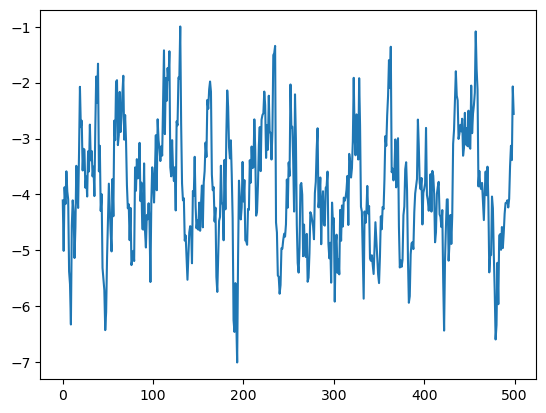

In [112]:
import matplotlib.pyplot as plt
plt.plot(spread)

In [113]:
from statsmodels.tsa.stattools import adfuller
adfuller(spread)

(np.float64(-6.872738901429747),
 np.float64(1.5011475011702219e-09),
 2,
 497,
 {'1%': np.float64(-3.4435761493506294),
  '5%': np.float64(-2.867372960189225),
  '10%': np.float64(-2.5698767442886696)},
 np.float64(975.5707818106152))